# Les figures du deck — partie II, les figures à PRIX

**Ce notebook produit les figures de la partie II de `SLIDES_DONNEES` qui exigent les prix** :
`P5b_duree` (durées de détention), `P7a_distributions` (performance des membres) et les
**8 portraits** `G_*_portrait`. Les 7 figures de population **sans prix** (P1, P2, P3, P4a, P4b,
P4c, P6) sont produites par la chaîne du rapport (`common/quality.py`, régénérées avec lui) —
zéro double calcul. Table : **la table clean du pipeline** (propre au sens plein, entonnoir A→F) ;
le deck, document figé, garde ses copies `figs_deck` (règle des figures du dépôt) ; les chiffres
régénérés diffèrent d'un cheveu des slides d'époque, assumé. Socle : `tools/membre` (prouvé par
`python -m tools.membre.test_ancres_membre`) + `tables/membres.csv` (les stats par membre, du
producteur unique `tables_membres_tickers`).

In [1]:
# ══ AMORÇAGE — tools/membre + la table des membres ══
%matplotlib inline
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import sys; sys.path.insert(0, "../..")
from tools.membre import donnees as mdon, moteur as mmot

MCTX = mdon.charger_membre()
df, dfx, prices, cal, r_spy = MCTX.df, MCTX.dfx, MCTX.prices, MCTX.cal, MCTX.r_spy
BEH = pd.read_csv(mdon.DOSSIER / "tables" / "membres.csv").set_index("bioguide_id")
FIGS = str(mdon.RACINE / "00_recuperation_donnees" / "png" / "figs_pop")
FIG = lambda n: os.path.join(FIGS, n + ".png")
C_BUY, C_SELL, C_SPY, C_M = "tab:green", "tab:red", "black", "tab:blue"
KW = dict(dpi=200, bbox_inches="tight", facecolor="white")
print(f"figures → {FIGS} | membres.csv : {BEH.shape}")

𝒯^brut (fenêtré, avant prix — table brute) : 134,417 trades | 372 membres | 4,607 tickers
clean (exploitable) : 118,316 trades | tickers avec prix 3,286 | sans prix 0 | corrompus 0 | jetés au chargement 0
figures → /Users/lemairealice/Downloads/Jupiter/00_recuperation_donnees/png/figs_pop | membres.csv : (372, 94)


## Étape B du deck — « Ils gardent leurs positions longtemps » (`P5b_duree`)

In [2]:
# épisodes de détention FIFO (tools.moteur.fifo_holding), agrégés sur tous les membres
closed_l, opened_l = [], []
for _, g in df.groupby("bioguide_id"):
    c, o = mmot.fifo_holding(MCTX, g)
    closed_l += c; opened_l += o
closed = pd.DataFrame(closed_l, columns=["duree", "parts"])
opened = pd.DataFrame(opened_l, columns=["duree", "parts"])
print(f"{len(closed):,} épisodes clos · {len(opened):,} encore ouverts")

62,136 épisodes clos · 29,051 encore ouverts


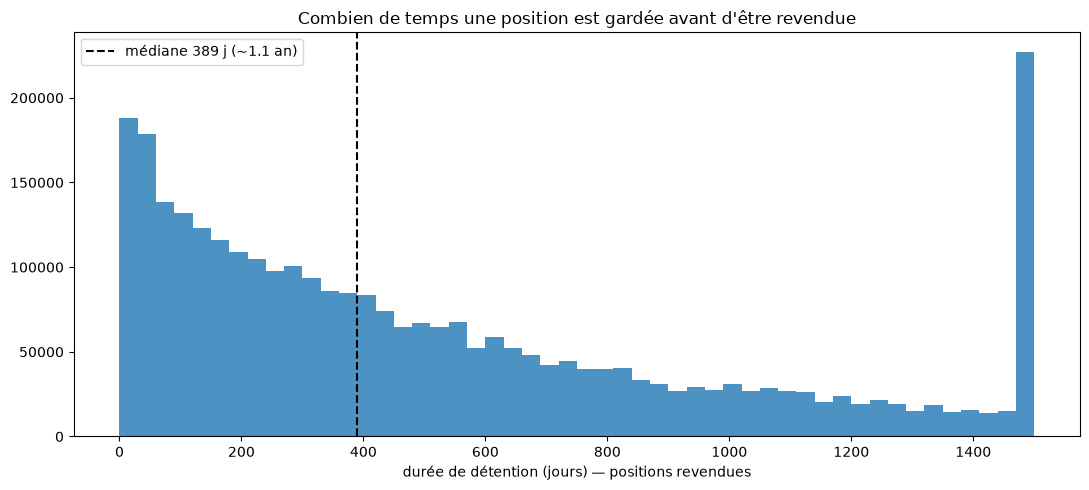

durée médiane revendues 389 j (~1.1 an) | 44% des positions jamais revendues


In [3]:
_w = np.maximum(1, (closed.parts.values/closed.parts.min()).round().astype(int).clip(max=50))
_dur = np.repeat(closed.duree.values, _w); _med = np.median(_dur)
_pct_open = opened.parts.sum() / (closed.parts.sum() + opened.parts.sum())
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(np.clip(_dur, 0, 1500), bins=50, color=C_M, alpha=.8)
ax.axvline(_med, color="k", ls="--", label=f"médiane {_med:.0f} j (~{_med/365:.1f} an)")
ax.set_xlabel("durée de détention (jours) — positions revendues"); ax.legend()
ax.set_title("Combien de temps une position est gardée avant d'être revendue")
plt.tight_layout(); fig.savefig(FIG('P5b_duree'), **KW); plt.show()
print(f"durée médiane revendues {_med:.0f} j (~{_med/365:.1f} an) | {_pct_open:.0%} des positions jamais revendues")

## Étape C du deck, l'ouverture — « le Congrès bat-il le marché ? » (`P7a_distributions`)

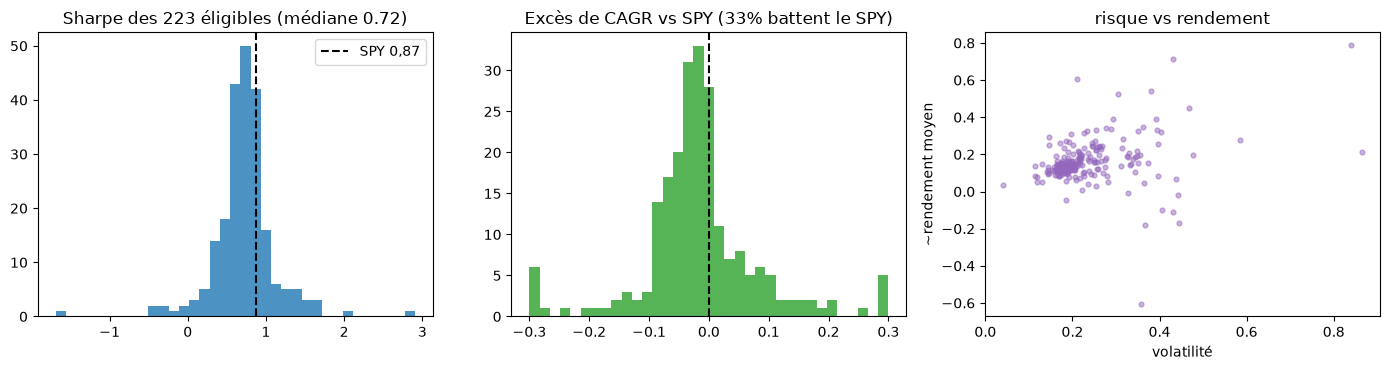

33% des éligibles battent le SPY sur LEUR fenêtre | Sharpe médian 0.72 vs SPY 0,87


In [4]:
_e = BEH[BEH.eligible.astype(str).str.lower().eq("true")].copy()
_pct_bat = (_e.exces_cagr_spy > 0).mean()
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
ax[0].hist(_e.sharpe, bins=35, color="tab:blue", alpha=.8); ax[0].axvline(0.87, color="k", ls="--", label="SPY 0,87")
ax[0].set_title(f"Sharpe des {len(_e)} éligibles (médiane {_e.sharpe.median():.2f})"); ax[0].legend()
ax[1].hist(_e.exces_cagr_spy.clip(-.3, .3), bins=35, color="tab:green", alpha=.8); ax[1].axvline(0, color="k", ls="--")
ax[1].set_title(f"Excès de CAGR vs SPY ({_pct_bat:.0%} battent le SPY)")
ax[2].scatter(_e.vol, _e.sharpe*_e.vol, s=12, alpha=.5, color="tab:purple")
ax[2].set_xlabel("volatilité"); ax[2].set_ylabel("~rendement moyen"); ax[2].set_title("risque vs rendement")
plt.tight_layout(); fig.savefig(FIG('P7a_distributions'), **KW); plt.show()
print(f"{_pct_bat:.0%} des éligibles battent le SPY sur LEUR fenêtre | Sharpe médian {_e.sharpe.median():.2f} vs SPY 0,87")

## Étape D du deck — les 8 portraits (`G_*_portrait`)

L'arc du deck : l'icône (Pelosi) → le contraste hyper-trader (Khanna) → le champion fragile
(Fetterman, 10 trades) → le solide modeste (Whitehouse, 718 trades) → le mirage du β (McClain) →
l'artefact appraisal (Ruiz) → l'anti-talent (Trott) → le scandale COVID (Burr, zoom 2019-2020).

In [5]:
# les séries de rendement des 8 seuls membres portraiturés (rapide)
PORTRAITS = ["P000197", "K000389", "F000479", "W000802", "M001136", "R000599", "T000475", "B001135"]
wf_ret = {}
for bid in PORTRAITS:
    g = df[df.bioguide_id == bid]
    N = mmot.member_shares(MCTX, g)
    wf_ret[bid] = mmot.daily_return(MCTX, N)
print({b: len(r) for b, r in wf_ret.items()})

{'P000197': 2914, 'K000389': 2373, 'F000479': 284, 'W000802': 3316, 'M001136': 580, 'R000599': 2261, 'T000475': 2854, 'B001135': 3114}


In [6]:
def portrait(bid, zoom=None, save=None):
    r = wf_ret[bid]; nav = 100*(1+r).cumprod()
    rs = r_spy.reindex(r.index).fillna(0.0); navs = 100*(1+rs).cumprod()
    g = df[df.bioguide_id == bid].sort_values("traded"); gx = dfx[dfx.bioguide_id == bid]
    N = mmot.member_shares(MCTX, g); P = pd.DataFrame({tk: prices[tk] for tk in N.columns})
    V = (N*P).sum(axis=1); act = V > 0; W = (N*P).div(V, axis=0)[act]
    top8 = W.mean().sort_values(ascending=False).head(8).index if W.shape[1] else []
    row = BEH.loc[bid]; nom = row["name"]
    fig = plt.figure(figsize=(13, 7.4))
    gs = fig.add_gridspec(2, 2)
    gsA = gs[0, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
    axA = fig.add_subplot(gsA[0]); axDD = fig.add_subplot(gsA[1], sharex=axA)
    axA.plot(nav.index, nav.values, color=C_M, lw=1.2, label=nom)
    axA.plot(navs.index, navs.values, color=C_SPY, lw=1.0, label="SPY")
    axA.set_yscale("log"); axA.set_title("(A) NAV vs SPY (log) + drawdown", fontsize=9)
    axA.legend(fontsize=6); axA.tick_params(labelbottom=False)
    axDD.fill_between(nav.index, (nav/nav.cummax()-1).values, color=C_SELL, alpha=.5)
    axDD.set_ylabel("drawdown", fontsize=7)
    axB = fig.add_subplot(gs[0, 1])
    for op, c in [("buy", C_BUY), ("sell", C_SELL)]:
        s = gx[gx.op == op]; axB.scatter(s.traded, s.size_usd, s=12, c=c, alpha=.5, label=op)
    axB.set_yscale("log"); axB.set_title("(B) trades (taille \$, log)", fontsize=9); axB.legend(fontsize=6)
    axC = fig.add_subplot(gs[1, 0])
    if len(top8):
        W[top8].plot.area(ax=axC, lw=0, alpha=.85, cmap="tab10"); axC.set_ylim(0, 1)
        axC.legend(fontsize=5, ncol=4, loc="upper center")
    axC.set_title("(C) poids des 8 principales positions", fontsize=9)
    axD = fig.add_subplot(gs[1, 1])
    _ye = pd.Series({y: ((1+r[r.index.year == y]).prod()-1) - ((1+rs[rs.index.year == y]).prod()-1)
                     for y in sorted(set(r.index.year))})
    axD.bar(_ye.index, 100*_ye.values, color=[C_BUY if v > 0 else C_SELL for v in _ye.values], alpha=.8)
    axD.axhline(0, color="k", lw=.6); axD.set_title("(D) excès annuel vs SPY (%)", fontsize=9)
    if zoom:
        for a in [axA, axDD, axB]: a.set_xlim(pd.Timestamp(zoom[0]), pd.Timestamp(zoom[1]))
    fig.suptitle(f"{nom} — {len(g)} trades | Sharpe {row['sharpe']:.2f} · maxDD {row['maxdd']:.0%} | "
                 f"β {row['beta']:.2f} · α {row['alpha_ann']:+.1%}/an (t {row['t_appr']:.2f}) · IR t {row['t_ir']:.2f} | "
                 f"conjoint {row['part_conjoint']:.0%}", fontweight="bold", fontsize=10.5)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    if save: plt.savefig(save, **KW)
    plt.show()
print("helper portrait prêt.")

helper portrait prêt.


<>:22: SyntaxWarning: invalid escape sequence '\$'
<>:22: SyntaxWarning: invalid escape sequence '\$'
/var/folders/c1/hv99dnpj5rvg5xdxf584cv280000gn/T/ipykernel_35540/1676012658.py:22: SyntaxWarning: invalid escape sequence '\$'
  axB.set_yscale("log"); axB.set_title("(B) trades (taille \$, log)", fontsize=9); axB.legend(fontsize=6)


=== Nancy Pelosi ===


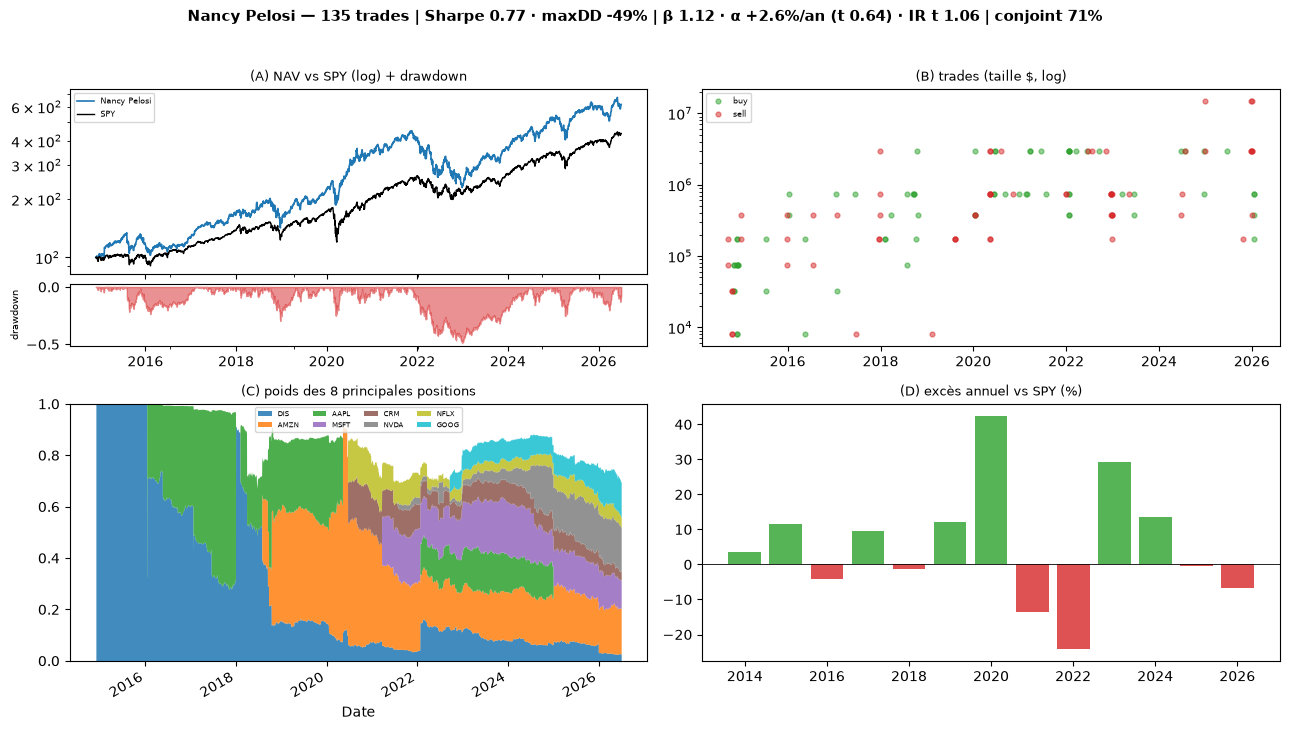

=== Rohit Khanna ===


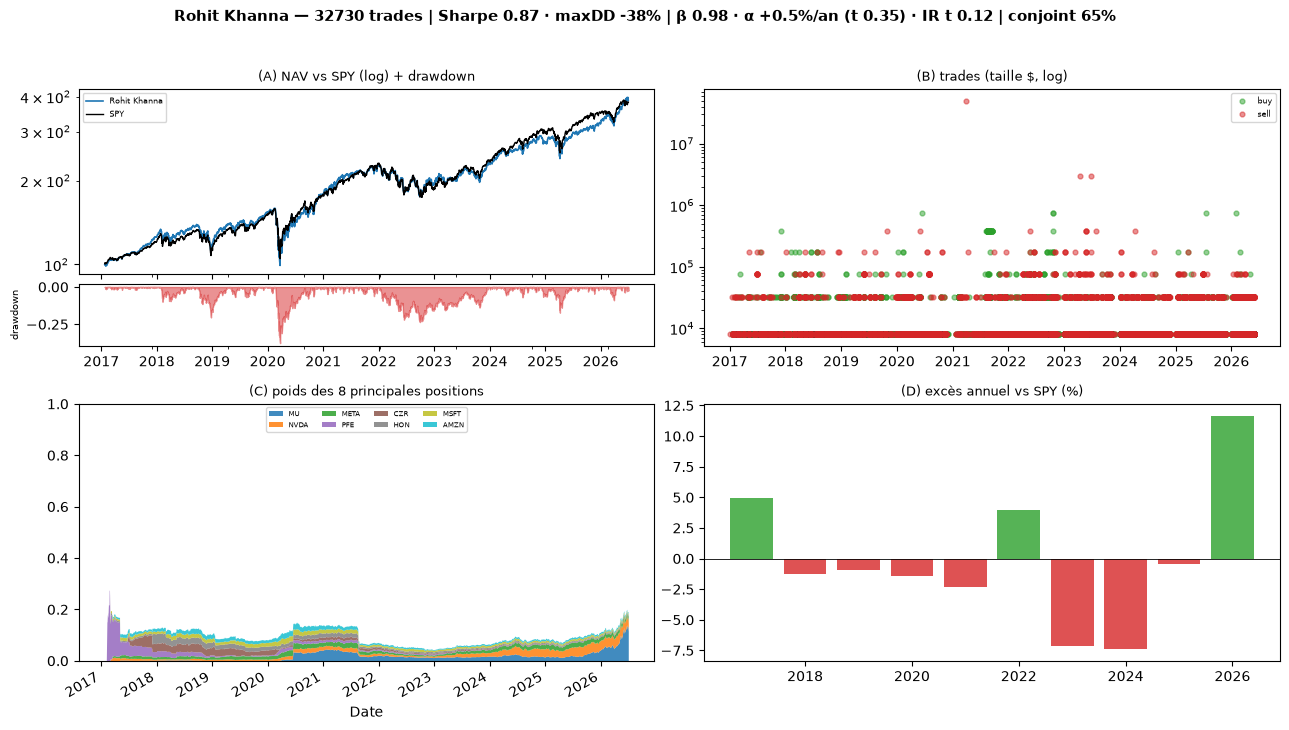

=== John Fetterman ===


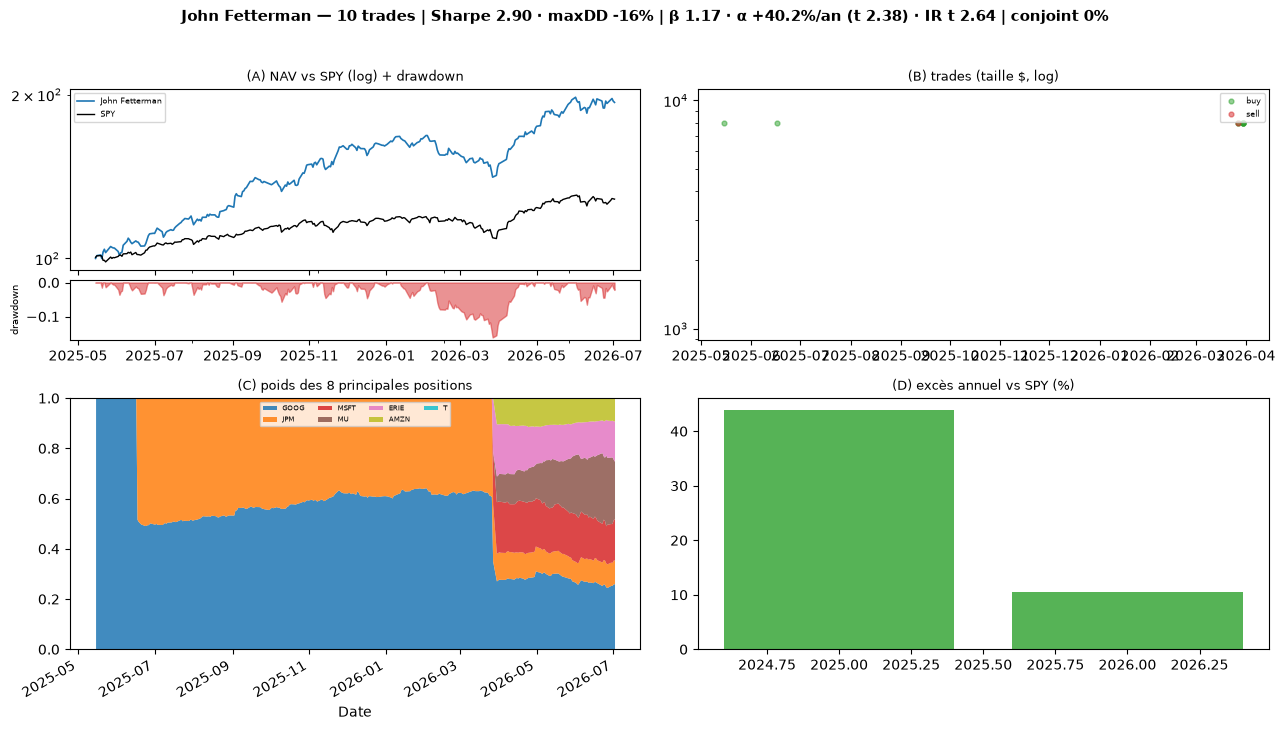

=== Sheldon Whitehouse ===


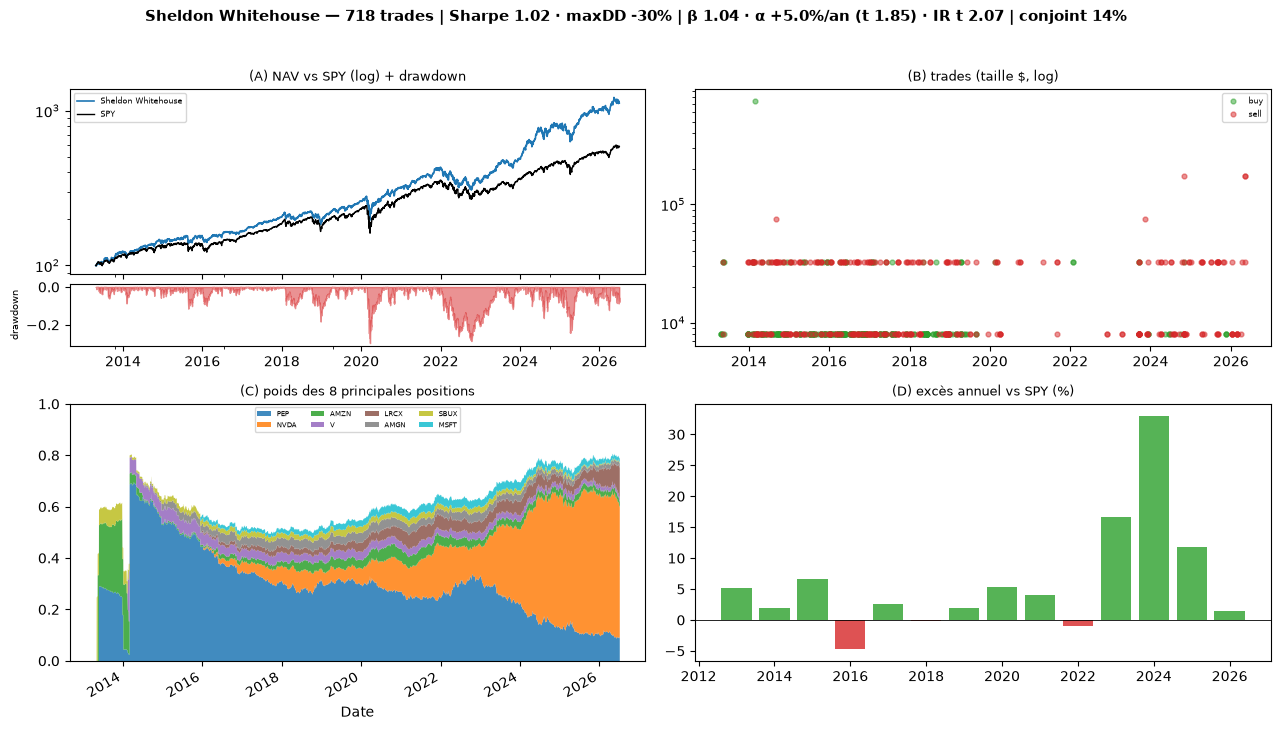

=== Lisa McClain ===


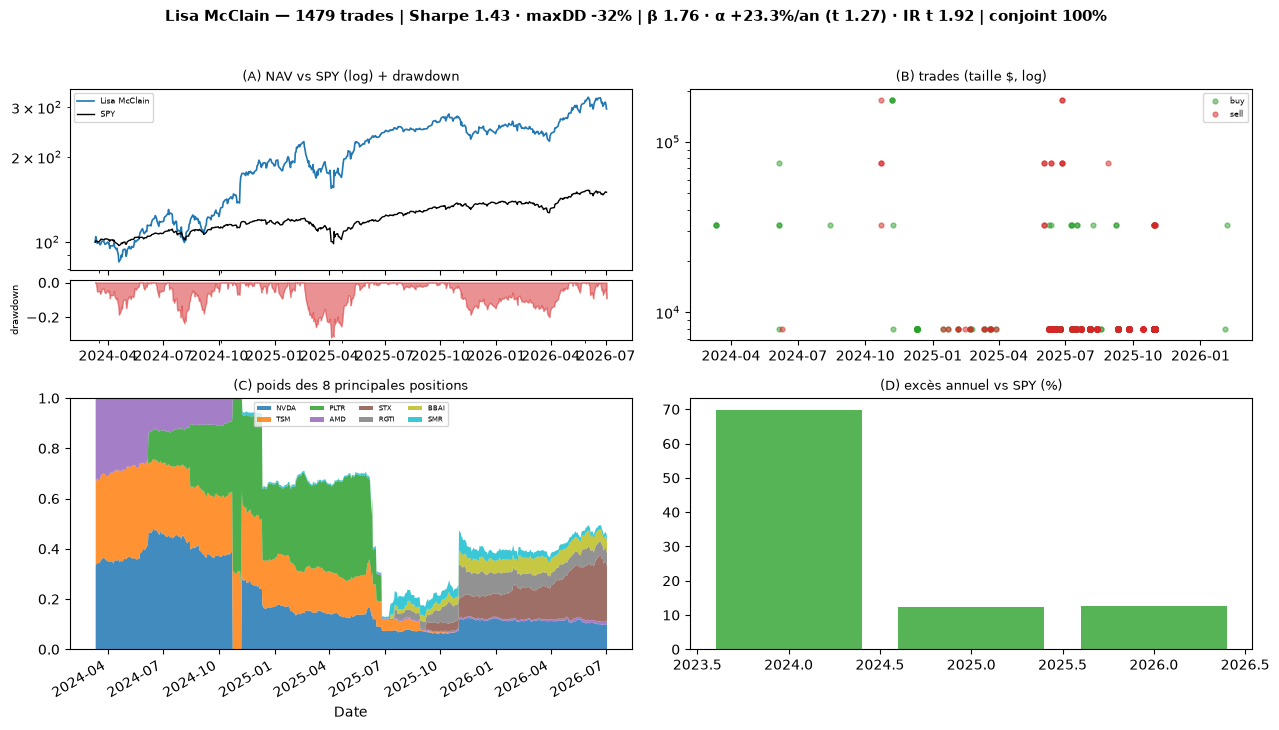

=== Raul Ruiz ===


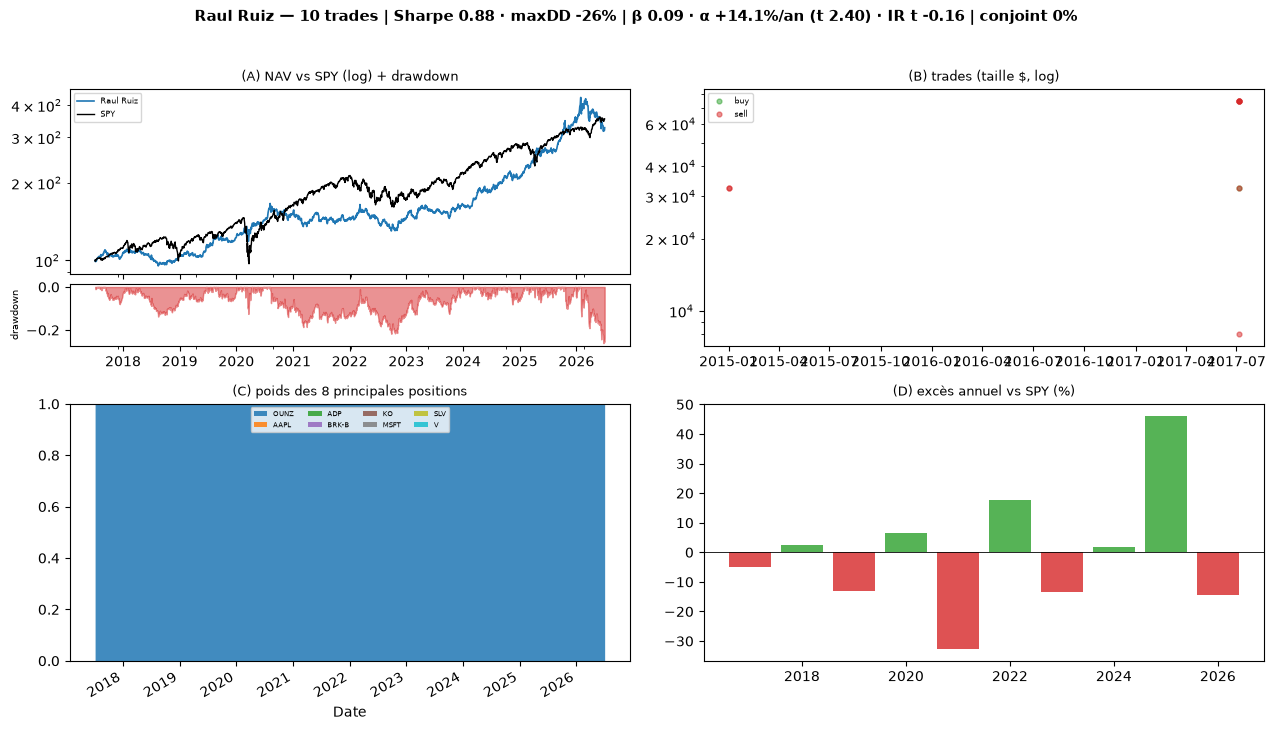

=== David A. Trott ===


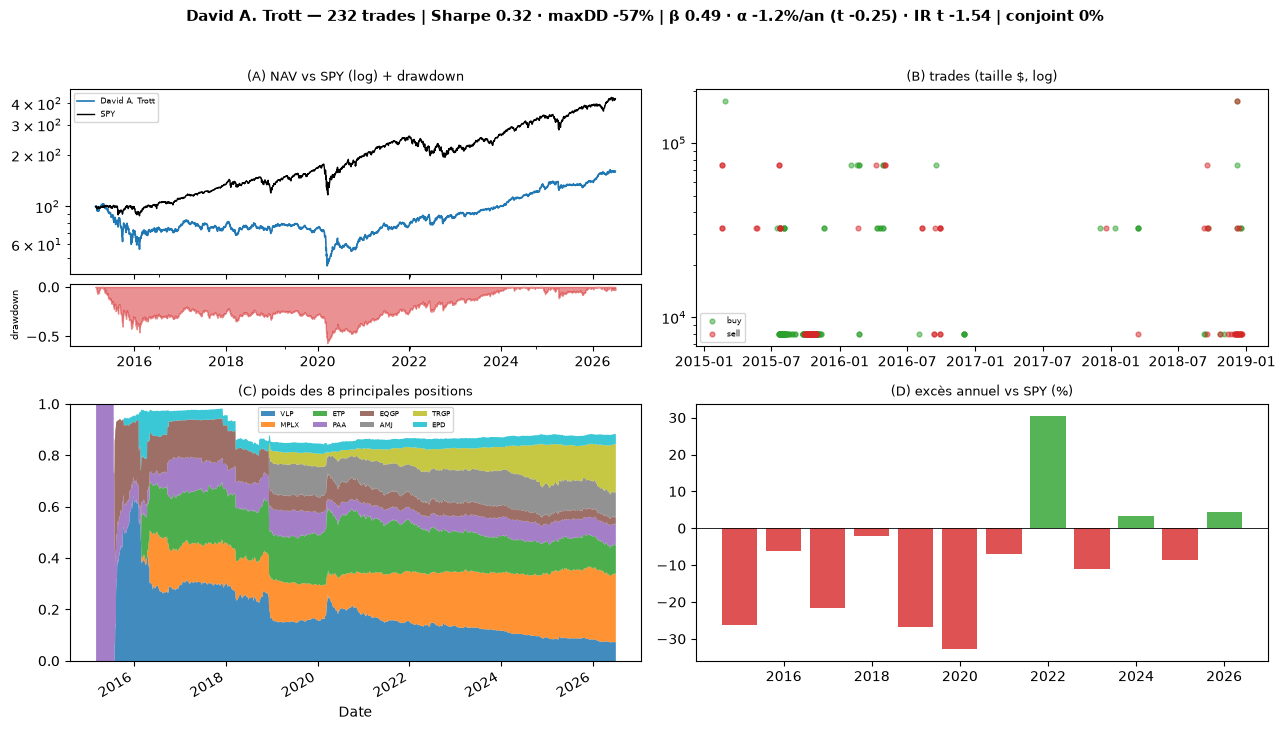

=== RICHARD M BURR ===


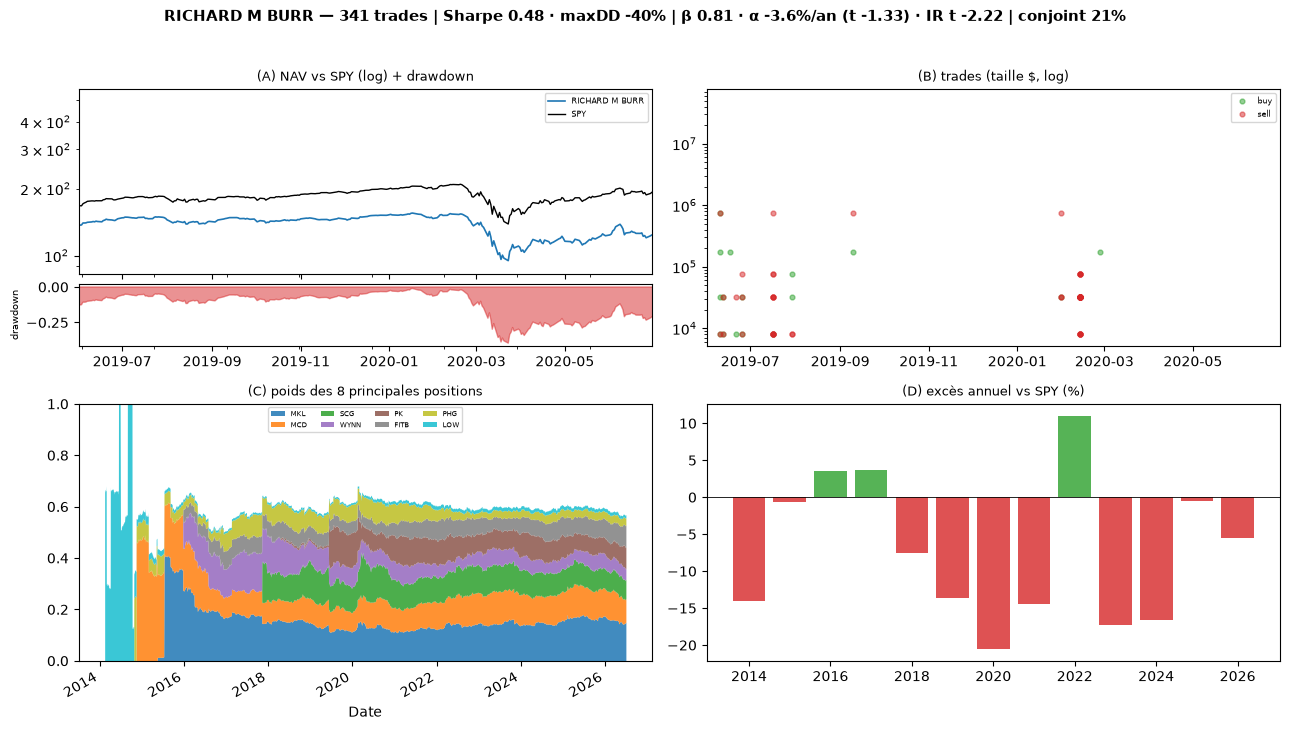

In [7]:
for bid in PORTRAITS:
    zoom = ("2019-06-01", "2020-06-30") if bid == "B001135" else None
    print(f"=== {BEH.loc[bid, 'name']} ===")
    portrait(bid, zoom=zoom, save=FIG(f"G_{bid}_portrait"))

In [8]:
# ══ CONTRAT DE SORTIE — figs_pop/ contient EXACTEMENT les 17 figures de la partie II ══
MIENNES = {"P5b_duree", "P7a_distributions"} | {f"G_{b}_portrait" for b in PORTRAITS}
DU_RAPPORT = {"P1_population_temps", "P2_top_membres", "P3_proprietaires", "P4a_fourchettes",
              "P4b_delai", "P4c_conflit", "P6_secteurs"}
sur_disque = {f[:-4] for f in os.listdir(FIGS) if f.endswith(".png")}
assert MIENNES <= sur_disque, f"figures manquantes : {MIENNES - sur_disque}"
assert DU_RAPPORT <= sur_disque, f"figures du rapport manquantes : {DU_RAPPORT - sur_disque}"
extra = sur_disque - MIENNES - DU_RAPPORT
assert not extra, f"figures orphelines dans figs_pop : {sorted(extra)}"
print(f"✅ figs_pop/ = exactement {len(MIENNES | DU_RAPPORT)} figures "
      f"({len(MIENNES)} de ce notebook + {len(DU_RAPPORT)} de common/quality.py)")

✅ figs_pop/ = exactement 17 figures (10 de ce notebook + 7 de common/quality.py)
